# CBP-Vet: deployment and the one-shot, end to end

This is part 2 of 2. Part 1, `CBP-Vet_Data-Engine_Walkthrough.ipynb`, builds and defends
the training data, freezes bench-v1, and banks the head-to-head: at the incumbent's own
sensitivity on the 0.15 to 0.30 percent depth stratum, 65 manual-inspection false
positives drop to 8 on the frozen test split. Its sections 10 and 11 close with the
models checkpointed under SHA-256 and the real planets still sealed.

This notebook picks up that exact thread. We froze the model; now we point it at the sky
and at the planets it has never been allowed to see. First the decisions that were pinned
before anything ran, then the deployment run over 63 live systems, the frozen model
ranking the real queue, the measured detectability of the whole chain, the ablation
ladder, and finally the sealed one-shot. Read part 1 first; every number here leans on
its freeze.

Every cell loads a real artifact from the real pipeline. Nothing is mocked.

One hard line throughout: the deployment shortlist exists and its dispositions are
recorded, but no candidate identity appears here. A shortlisted event is a
candidate-shaped thing attached to a real star, and naming one in a walkthrough is how
rumors start. Counts and distributions only.

In [1]:
import os, json, warnings
warnings.filterwarnings('ignore')
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

REPO = os.path.expanduser('~/cbp-vet')
os.chdir(REPO)
plt.rcParams.update({'figure.dpi': 110, 'font.size': 9, 'axes.grid': True,
                     'grid.alpha': 0.25, 'axes.spines.top': False, 'axes.spines.right': False})
print('repo:', REPO)

repo: /Users/wilsonwu/cbp-vet


---
## 1. What was pinned before anything ran

Part 1 froze the data and the model. Before the deployment fork, the remaining open
decision rules were each stress-tested, an independent case-builder plus an adversarial
attacker per pin, and adopted as registry section H (H1 to H9). The reason to pin first
is the same as ever: once results exist, every choice looks like it was made to flatter
them.

- **H1, detectability is measured per system, not only in aggregate.** The board's rule
  asked for per-system curves on the golden systems, and a timed pilot through the
  identical injection harness measured 0.60 s per injection against the pinned 2.5 s
  gate, so there was no timing excuse to override the rule. One golden system has zero
  files outside the frozen 1,946 light curves, so the headline program covers 27 of 28,
  disclosed, and the 28th appears only in the overlap-included secondary program.
- **H2, deployment-native injections are a fourth provenance, built by the same dual
  harness.** Same 50/50 inverted-versus-native split, same per-test mix gate, and the
  native arm masks the deployment search's own detected events exactly as the benchmark
  campaign consumed the frozen search's. The provenance string `deploy_native` lives on
  injector rows and run metadata only; anything passing the frozen exporter keeps the
  closed schema's `bank_injection`, and nothing is ever merged into bench-v1.
- **H3, the bracketed [Y] in every headline means false positives only.** The metric is
  "manual-inspection false positives per 1,000 light curves at matched recall". The
  alternative, fp plus tp, is not even a single well-defined quantity (1,161 versus
  5,153 for the same model and operating point, depending on the positive pool), and an
  injection-enriched test set's true-positive volume reflects injection density, so it
  would overstate a real queue's workload by two orders of magnitude.
- **H4 plus H9, the reduced Kepler tier, and the audit that bit us.** H4 set the
  one-shot's Kepler tier as a floor (Kepler-16, Kepler-34) plus a capped stretch
  (Kepler-35, Kepler-1647), with a rider: resolve all ten Kepler planet hosts' TESS
  identities and intersect them with the catalogs, in one batch. That rider earned its
  keep. Five of the ten hosts turned out to sit in the source catalogue, with TESS light
  curves inside the frozen 1,946, which means our own frozen training split contained
  planet-host data the exclusion list never saw. Measured in the frozen shard: 175 of
  105,680 kept-train rows (0.166 percent) come from planet-host systems, and exactly 2
  of them are the risky class, real-search negatives that could in principle hide a real
  transit labelled junk. Root cause, told plainly: at split time the exclusion list held
  only the three TESS-planet identifiers, because the Kepler hosts' TESS identities had
  never been resolved. Nobody hid anything; the check that would have caught it simply
  had not been run yet, and the pinned rider is what finally ran it. The bias direction
  is against us (a hidden real transit trains the model to call planets junk), training
  positives remain 100 percent synthetic, bench-v1 stays frozen with the disclosure in
  its errata rather than being quietly rebuilt, the exclusion list now carries all
  thirteen hosts so no future split can repeat this, and Kepler-1647, whose extracted
  events sit in train, is dropped from the declared tier. The tier is Kepler-16 + 34 +
  35, every host bright-line clean.
- **H5, a masking asymmetry is disclosed, not shimmed.** Staged text files carry no
  eclipse-mask column, so 30-minute-cadence files inject with no per-cadence eclipse
  exclusion while faster files get catalog-recomputed masks. The benchmark campaign
  itself ran exactly this way on the same file format, so a deployment-only shim would
  create an inconsistency with the banked construction instead of fixing one. The
  harness stays identical, the regime is disclosed in the run metadata and captions, and
  the shim is parked as fall scope.
- **H6 and H7, small pins recorded rather than improvised.** The 15-column shortlist
  format (local only, per the standing privacy rule), and the one-shot matching
  tolerance max(t_dur/2, published t_unc) per row, because three of TOI-1338 b's
  published mid-times are quoted only to the nearest day, and a tighter tolerance would
  fail transits for the literature's precision, not the pipeline's performance.

---
## 2. The deployment run: 63 systems, 316 files, one fork

The deployment target is the 63 catalogue-overlap systems with usable ephemerides, the
only systems the masker can be pointed at today. Their cached light curves are staged as
copies into `data/deploy_staged/lc`. Copies, never symlinks: the masker rewrites its
input files in place, and a symlinked staging would have silently corrupted the frozen
light-curve cache that bench-v1's provenance depends on.

The second crash mode was subtler and is worth telling properly. The search's Skye
metric indexes a sector-times table as `values[sector - 1]`. The shipped table ends at
row 98; the staged QLP files reach sector 103. So the staging script wrote an extended
table, rows 1 to 98 value-identical to the original and rows 99 to 103 bounded by the
staged files' own time ranges, with the mono-cbp original never touched. Then the fix
was proven in both directions: a smoke run on sector-100 and sector-101 files passes
with the extended table, and a negative control on the original table crashes with
exactly `IndexError: index 99 is out of bounds for axis 0 with size 98`, the failure the
recipe predicted a week before it could have happened. A fix proven by its own failure
case is worth two proven only by success.

In [2]:
man = json.load(open('data/deploy_staged/staging_manifest.json'))
meta = json.load(open('data/deploy_run/search/run_meta.json'))

print('THE FUNNEL'.center(58, '-'))
print(f"  systems targeted        : {man['n_tics']}")
print(f"  cache files matched     : {man['n_cache_matches']}")
print(f"  staged (copies, hashed) : {man['n_staged']}    "
      f"({len(man['excluded'])} mis-named cache file excluded, recorded in the manifest)")
print(f"  searched                : {meta['n_files_searched']}    (exclusions at search time: {len(meta['excluded'])})")
print(f"  events flagged          : {meta['n_events']:,}  from {meta['n_tics_with_events']} systems "
      f"({man['n_tics'] - meta['n_tics_with_events']} produced none)")
print()
print(f"runtime: mask {meta['runtime_s']['mask']:.1f} s + find {meta['runtime_s']['find']:.1f} s for all "
      f"{meta['n_files_searched']} files - the search itself was never the expensive part")
print(f"every masked input hashed: {len(meta['masked_input_sha256'])} SHA-256 entries in run_meta")
print()
print('THE MACHINERY THAT HAD TO EXIST FIRST'.center(58, '-'))
print(f"  max staged sector {man['max_staged_sector']} vs {man['shipped_sector_rows']} rows in the shipped sector-times table")
assert man['extended_rows_added'] == [99, 100, 101, 102, 103], 'extended-table rows drifted'
print(f"  extended rows added: {man['extended_rows_added']}   (original table untouched; extended CSV hashed)")
assert meta['sector_times'].endswith('sector_times_extended.csv'), 'search did not consume the extended table'
print('  consistency check: the search consumed the EXTENDED table, per its own run_meta  OK')

------------------------THE FUNNEL------------------------
  systems targeted        : 63
  cache files matched     : 317
  staged (copies, hashed) : 316    (1 mis-named cache file excluded, recorded in the manifest)
  searched                : 316    (exclusions at search time: 0)
  events flagged          : 991  from 62 systems (1 produced none)

runtime: mask 2.5 s + find 246.2 s for all 316 files - the search itself was never the expensive part
every masked input hashed: 316 SHA-256 entries in run_meta

----------THE MACHINERY THAT HAD TO EXIST FIRST-----------
  max staged sector 103 vs 98 rows in the shipped sector-times table
  extended rows added: [99, 100, 101, 102, 103]   (original table untouched; extended CSV hashed)
  consistency check: the search consumed the EXTENDED table, per its own run_meta  OK


---
## 3. The frozen model ranks the real queue

This is the product doing its job. The 991 flagged events go through the incumbent's
comparator and the frozen exporter (tool use, not an unfreeze), and the frozen arm-b
checkpoint scores them, hash-asserted before any scoring. Nothing was retrained, and the
threshold below is the banked matched-recall tau from part 1's head-to-head, carried over
verbatim.

Two disclosures before the histogram, because they change how the tail should be read.

- **Eight of the top fifty rows were scored on a zero-filled incumbent block.** Their
  comparator runs failed, whole files at a time: 81 dropped events, 8 files, 6 systems,
  all in late and extended sectors. An empty best-fit label there means "comparator
  failed", not "no preferred model", and the model ranked some of those rows high partly
  because the incumbent block was silent. The disposition review weighed them knowing
  that.
- **82 of the 316 files overlap the frozen search's staged set** (208 of the 991
  events), flagged per event in the ranked table. The headline detectability programs
  exclude those files; the ranking here is deployment, not evaluation, so overlap is
  disclosed rather than dropped.

The shortlist exists: the top 50 by frozen score, the 15 pinned columns, every row
dispositioned by hand. It stays local. What can be shown is the shape of the queue and
what the human found at the top of it.

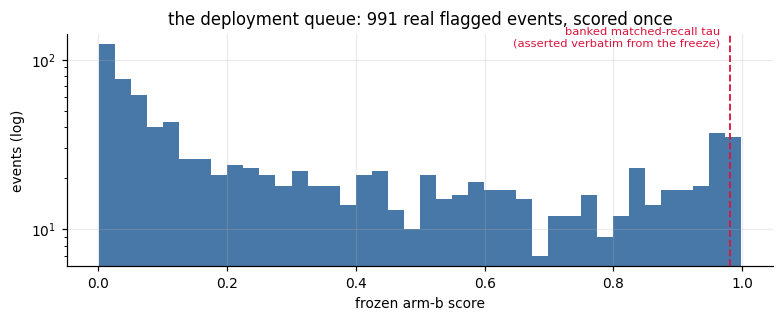

median score 0.288, p90 0.912, p99 0.991  (recomputed from ranked_all, matches the banked summary)
22 events clear the banked tau; shortlist v1 = top 50, 15 pinned columns, LOCAL ONLY
incumbent block valid on 91.8% of events (the zero-filled disclosure above); comparator cost 13 ms/event

WHAT THE HUMAN FOUND AT THE TOP (all 50 shortlist rows dispositioned):
   eclipse-residual       35
   detrending-artifact    10
   gap-systematic          5
   plausible-candidate     0
   ambiguous               0

No planetary-quality candidate survives the battery: every top-50 event lands in a
named junk class with a concrete mechanism. One system alone contributes 17 of the 50,
a family of stellar-depth dips at scattered binary phases, most plausibly an unmodeled
extra eclipser or a blended binary. Astrophysically interesting, not a planet.
A null over 63 systems is the expected outcome; real circumbinary planets are rare.
The product is the ranking plus the recorded dispositions, not a discover

In [3]:
sc = json.load(open('data/deploy_run/score/deploy_score_summary.json'))
hashlog = json.load(open('data/bench/full/preshot_hashlog_2026-08-07.json'))
tau = hashlog['operating_threshold']['value']
assert sc['checkpoint_sha256'] == hashlog['scoring_model']['sha256'], 'scored with a different checkpoint'

# ranked_all is loaded WITHOUT its identity column, on purpose (the privacy hard line):
r = pd.read_csv('data/deploy_run/score/ranked_all.csv', usecols=['arm_b_score', 'sector_overlap_frozen'])
scores = r.arm_b_score.values
assert len(scores) == sc['n_records'] == 991
assert int((r.sector_overlap_frozen > 0).sum()) == sc['sector_overlap_frozen_events'] == 208

fig, ax = plt.subplots(figsize=(7.2, 3.0))
ax.hist(scores, bins=40, color='#4878a8')
ax.axvline(tau, color='crimson', ls='--', lw=1.2)
ax.text(tau - 0.015, 120, 'banked matched-recall tau\n(asserted verbatim from the freeze)',
        color='crimson', fontsize=7.5, ha='right')
ax.set(yscale='log', xlabel='frozen arm-b score', ylabel='events (log)',
       title=f'the deployment queue: {len(scores):,} real flagged events, scored once')
plt.tight_layout(); plt.show()

n_above = int((scores >= tau).sum())
assert n_above == sc['n_above_banked_tau'] == 22
for q in ('0.5', '0.9', '0.99'):
    assert abs(np.quantile(scores, float(q)) - sc['score_quantiles'][q]) < 1e-3
print(f"median score {sc['score_quantiles']['0.5']:.3f}, p90 {sc['score_quantiles']['0.9']:.3f}, "
      f"p99 {sc['score_quantiles']['0.99']:.3f}  (recomputed from ranked_all, matches the banked summary)")
print(f"{n_above} events clear the banked tau; shortlist v1 = top 50, 15 pinned columns, LOCAL ONLY")
print(f"incumbent block valid on {100*sc['incumbent_valid_fraction']:.1f}% of events "
      f"(the zero-filled disclosure above); comparator cost {sc['comparator_s_per_event']*1000:.0f} ms/event")
print()
print('WHAT THE HUMAN FOUND AT THE TOP (all 50 shortlist rows dispositioned):')
disp = pd.read_csv('data/deploy_run/review/shortlist_v1_dispositions.csv', usecols=['disposition'])
for cls in ['eclipse-residual', 'detrending-artifact', 'gap-systematic', 'plausible-candidate', 'ambiguous']:
    print(f"   {cls:22s} {int((disp.disposition == cls).sum()):2d}")
assert len(disp) == 50 and (disp.disposition == 'plausible-candidate').sum() == 0
print()
print('No planetary-quality candidate survives the battery: every top-50 event lands in a')
print('named junk class with a concrete mechanism. One system alone contributes 17 of the 50,')
print('a family of stellar-depth dips at scattered binary phases, most plausibly an unmodeled')
print('extra eclipser or a blended binary. Astrophysically interesting, not a planet.')
print('A null over 63 systems is the expected outcome; real circumbinary planets are rare.')
print('The product is the ranking plus the recorded dispositions, not a discovery claim.')
print()
print('verification: all 991 events independently re-scored through the single scoring gate,')
print('max drift 3.0e-08 (float32 CSV rounding scale); the 30-check deployment verifier passed')
print('(durable copy: data/deploy_run/verify_deploy.py).')

---
## 4. Detectability: what the chain can see, measured on itself

The deployment run says what we found in these 63 systems: nothing, honestly
dispositioned. Detectability answers the question that makes a null meaningful: what
would we have found, had it been there? The H2 harness injects bank transits into the
same staged, eclipse-masked copies the deployment search processed, runs the same
search, and scores every recovered event with the same frozen checkpoint at the same
banked tau. Completeness of the search-plus-vetter chain as benchmarked, not of a
friendlier proxy.

Three programs: per-system curves for the golden 27 (150 injections each), an aggregate
over the remaining disjoint files, and an overlap-included secondary over all 63
systems. The headline uses disjoint files only, per H1's scoping.

The mix gates did their job in both directions. Per-system 0.5010 pass, aggregate 0.498
pass, and the secondary program measured 0.527 inverted, a fail, so the pre-named
rebalance fired before any rate was quoted from it: the over-represented inverted tests
were subsampled out at a recorded seed. A gate that fails and triggers its pre-written
remedy is worth more than ten that pass.

One axis caveat, stated on every surface that uses it: the x axis is the square root of
the injected model depth, a limb-darkening-blind proxy for the planet-to-star radius
ratio, off by up to about 13 percent from the bank's true stored ratio. It is labelled
sqrt(model depth), never r_p/R_*. And a correction told on ourselves: the first write of
that column was all-NaN from a column-name slip; it was recomputed as sqrt of the
injected depth, the intended derivation exactly, the file rewritten and rehashed, all
recorded in the campaign summary's corrections list rather than silently.

In [4]:
camp = json.load(open('data/deploy_run/detectability/campaign_summary.json'))
cur = json.load(open('data/deploy_run/detectability/curves/curves_summary.json'))
assert cur['checkpoint_sha256'] == sc['checkpoint_sha256'], 'detectability scored with a different model'
assert cur['tau_used'] == tau, 'detectability used a different operating threshold'

print(f"campaign: {camp['n_tests']:,} injection tests -> {camp['n_recovered']:,} recovered by the search "
      f"-> {camp['n_events']:,} events")
t = camp['timing']
print(f"timing: {t['total_s']/3600:.2f} h total; first-100 re-timing {t['mean_s_per_injection_first100']:.2f} s/injection "
      f"vs the 2.5 s gate -> PASS")
assert t['gate_2p5s_pass'] and not t['flip_to_aggregate_fired'] and not t['tripwire_90min_fired']
print('        the aggregate-only flip never fired; the 90-minute tripwire never fired')
print()
print('MIX GATES (per-test inverted rate; gate |deviation| <= 0.02):')
for name, m in camp['inversion_mix_by_program_class'].items():
    verdict = 'PASS' if m['gate_pass'] else 'FAIL -> pre-named rebalance fired'
    print(f"   {name:16s} n={m['n']:5,d}   inverted {m['inverted_rate']:.4f}   {verdict}")
reb = cur['secondary_all63_rebalanced']
print(f"   secondary rebalance: {reb['n_tests_before']:,} -> {reb['n_tests_after']:,} tests "
      f"({reb['n_dropped_inverted']} inverted dropped, seed {reb['rebalance_seed']}), "
      f"mix {reb['mix_before']:.3f} -> {reb['mix_after']:.3f}")
print()
h = cur['headline']
print(f"HEADLINE (disjoint-only programs): {h['n_tests']:,} tests, {h['n_recovered']:,} recovered,")
print(f"{h['n_vetter_pass']:,} of the recovered pass the frozen vetter at the banked tau")
print(f"axis: {cur['axis']['label']}")
print(f"caveat, verbatim from the summary: {cur['axis']['caveat'].split(' (')[0]}")
print()
tab = pd.DataFrame(h['bins'])[['bin_center', 'n_tests', 'n_recovered',
                               'recovered_frac', 'vetter_pass_frac_of_recovered']]
tab.columns = ['sqrt(model depth)', 'tests', 'recovered', 'search recovered', 'vetter pass | recovered']
print(tab.round(3).to_string(index=False))
print()
print('Read the last column remembering what tau is: the banked OP-B matched-recall point,')
print('deliberately strict (0.345 recall at 8 false positives in the head-to-head). The')
print('shallow bins are the completeness price of the queue reduction, measured per bin')
print('with Wilson 68% intervals instead of assumed.')

campaign: 7,050 injection tests -> 4,890 recovered by the search -> 28,210 events
timing: 1.16 h total; first-100 re-timing 0.43 s/injection vs the 2.5 s gate -> PASS
        the aggregate-only flip never fired; the 90-minute tripwire never fired

MIX GATES (per-test inverted rate; gate |deviation| <= 0.02):
   per_system       n=4,050   inverted 0.5010   PASS
   aggregate        n=2,000   inverted 0.4980   PASS
   secondary_all63  n=1,000   inverted 0.5270   FAIL -> pre-named rebalance fired
   secondary rebalance: 1,000 -> 946 tests (54 inverted dropped, seed 20260807), mix 0.527 -> 0.500

HEADLINE (disjoint-only programs): 6,050 tests, 4,166 recovered,
1,596 of the recovered pass the frozen vetter at the banked tau
axis: sqrt(model depth)
caveat, verbatim from the summary: sqrt(inj_depth): limb-darkening-blind proxy for the bank's true stored ratio, deviations up to ~13%

 sqrt(model depth)  tests  recovered  search recovered  vetter pass | recovered
             0.037   1240       

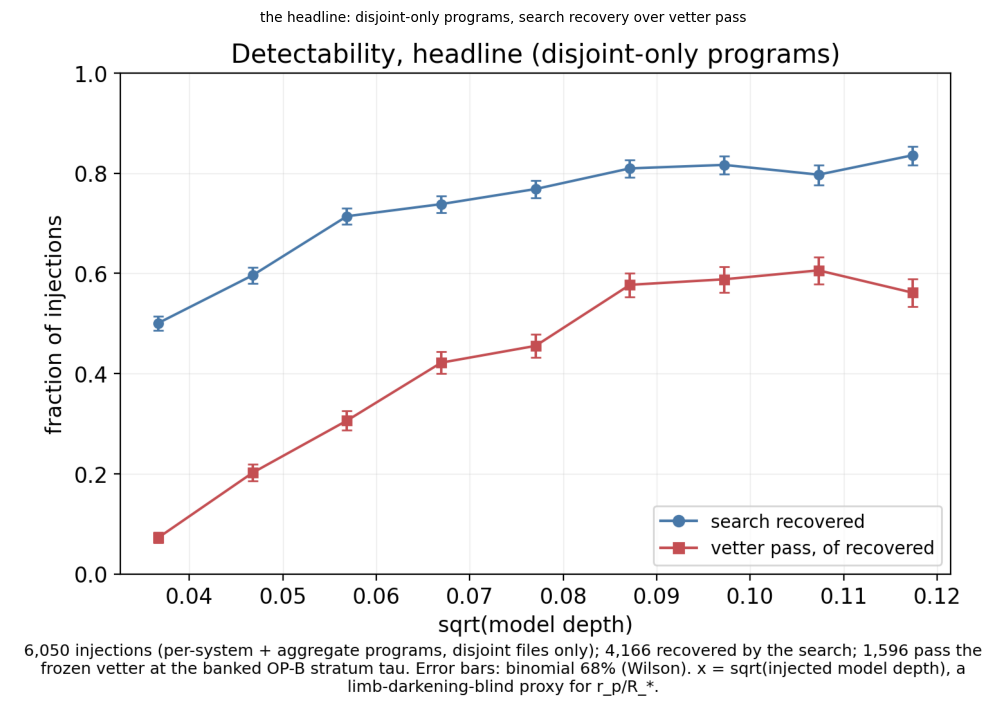

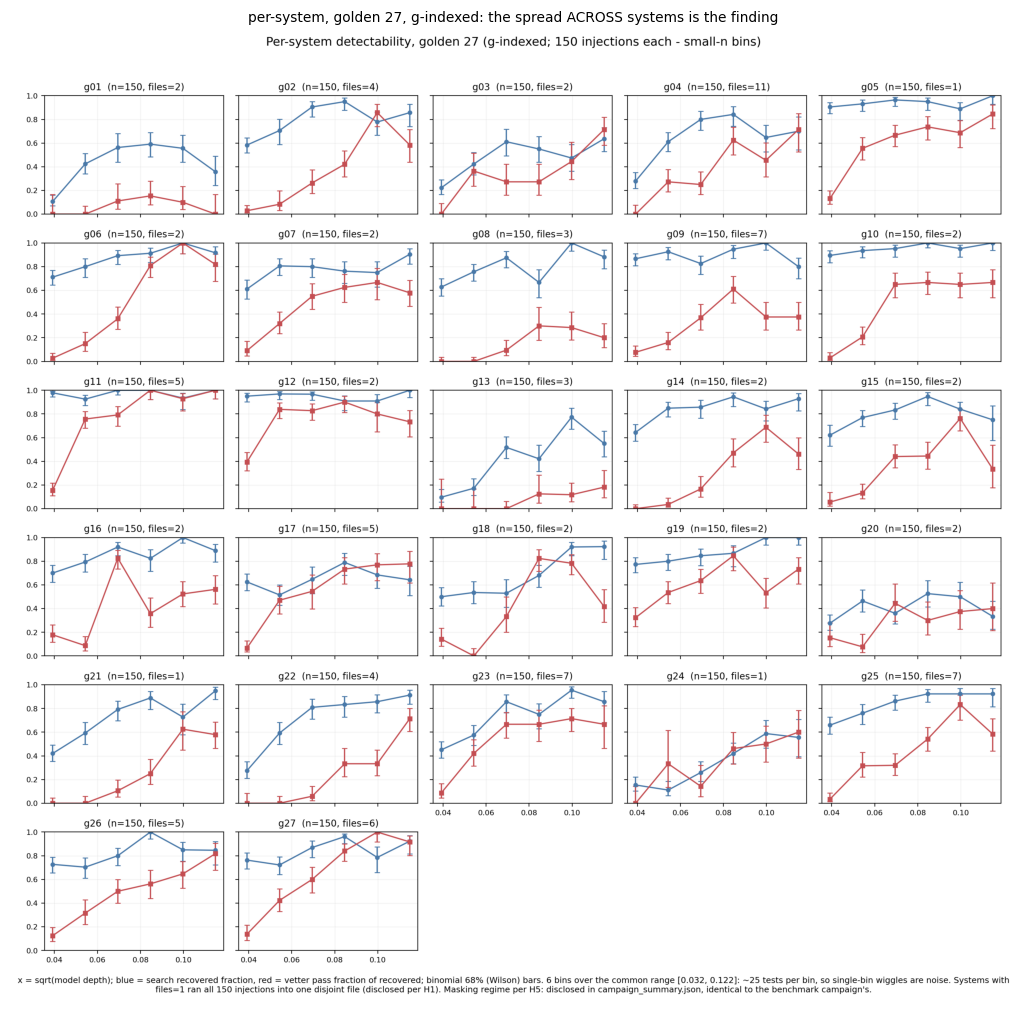

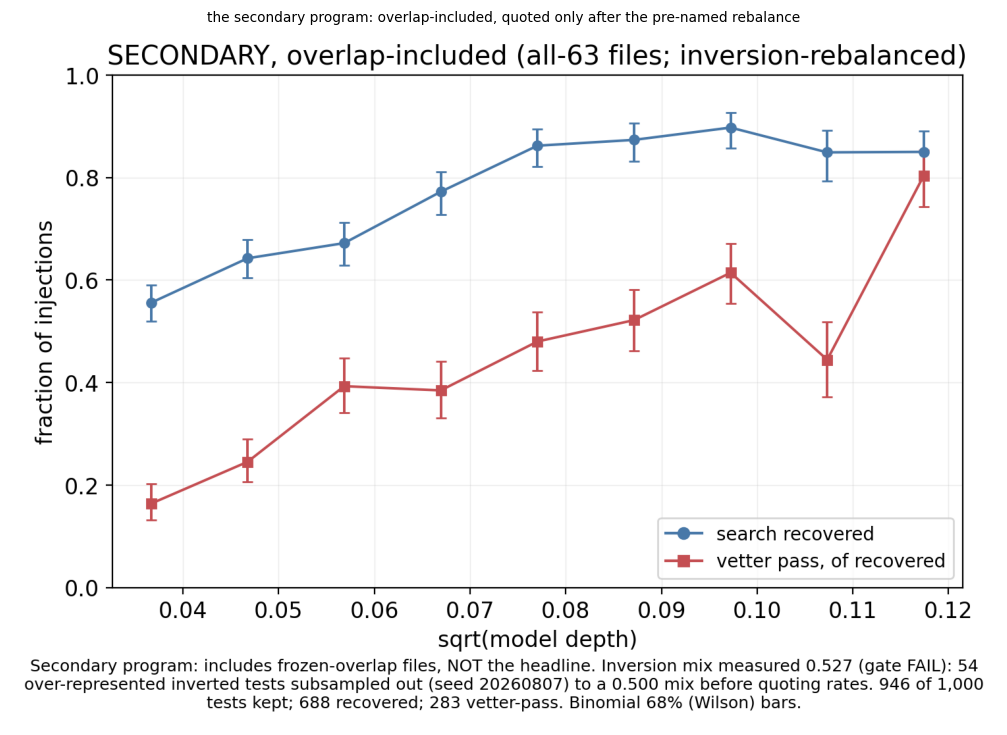

The per-system grid is g-indexed on purpose: the g-to-system mapping is a LOCAL_ONLY
key inside curves_summary.json and is never rendered here. Small-n honesty: about 25
tests per bin per system, so single-bin wiggles are noise. The masking-regime
disclosure (H5) rides the campaign metadata and these captions.


In [5]:
captions = [
    ('data/deploy_run/detectability/curves/headline_curve.png',
     'the headline: disjoint-only programs, search recovery over vetter pass'),
    ('data/deploy_run/detectability/curves/per_system_golden27.png',
     'per-system, golden 27, g-indexed: the spread ACROSS systems is the finding'),
    ('data/deploy_run/detectability/curves/secondary_rebalanced_curve.png',
     'the secondary program: overlap-included, quoted only after the pre-named rebalance'),
]
for path, cap in captions:
    img = plt.imread(path)
    w = 9.6
    fig, ax = plt.subplots(figsize=(w, w * img.shape[0] / img.shape[1]))
    ax.imshow(img); ax.axis('off'); ax.grid(False)
    ax.set_title(cap, fontsize=9)
    plt.tight_layout(); plt.show()

print('The per-system grid is g-indexed on purpose: the g-to-system mapping is a LOCAL_ONLY')
print('key inside curves_summary.json and is never rendered here. Small-n honesty: about 25')
print('tests per bin per system, so single-bin wiggles are noise. The masking-regime')
print('disclosure (H5) rides the campaign metadata and these captions.')

---
## 5. The ablation ladder: where the 8x actually comes from

Part 1's head-to-head says the model wins. The ladder says why, in two steps, under the
exact protocol of the banked table: same seed, same grid, selection on validation PR-AUC
only, same matched-recall harness. The two endpoints, arm b0 and arm b, are read from
the banked record and never recomputed; only the middle rung ran fresh, which pulled it
forward from its fall parking.

- **arm b0**, the incumbent's own 17 columns and nothing else: 63 false positives,
  statistically the incumbent's own 65. Information parity reproduces the incumbent.
- **arm b_nopair**, 33 features, everything except the observed-pair physics: 13.
- **arm b**, all 37 offered features: 8.

Read it as two steps. The event-and-context features the incumbent computes but throws
away or never had, the 21-window detection count, the recurrence stack, the phase and
gap context, do most of the work: 63 down to 13. The observed-pair physics, features
that encode whether a second dip sits where a circumbinary partner transit would sit,
buys the last step: 13 to 8. Context first, physics second, and nothing about a CNN
anywhere.

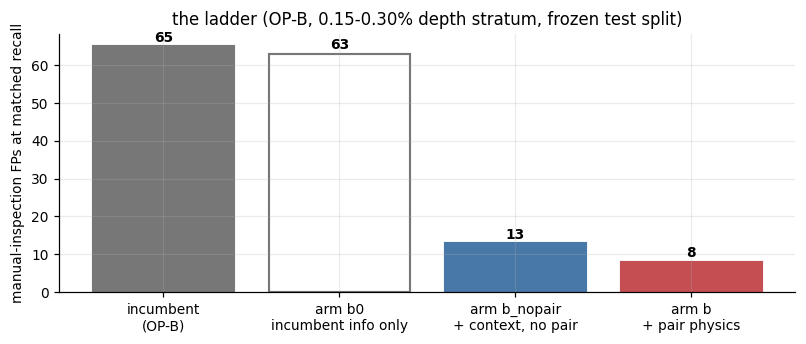

middle rung selected on validation PR-AUC alone (0.8718, xgboost), test touched once
matched recall at the rung: 0.345, the incumbent's own stratum recall - the denominator never moves

two-step reading: 63 -> 13 from context features the incumbent discards,
13 -> 8 from the observed-pair physics.
banked convention: pair-feature contribution = b_nopair FP minus b FP at matched recall; positive means the pair features reduce the queue.


In [6]:
lad = json.load(open('data/bench/full/ablation_ladder_2026-08-07.json'))
fp_b0 = lad['banked_b0_OPB_stratum_fp']
fp_np = lad['b_nopair']['OPB_stratum']['queue_fp_only']
fp_b = lad['banked_b_OPB_stratum_fp']
assert (fp_b0, fp_np, fp_b) == (63, 13, 8), 'ladder drifted from the banked values'
assert lad['b_nopair']['selected_model'] == 'xgboost'

labels = ['incumbent\n(OP-B)', 'arm b0\nincumbent info only', 'arm b_nopair\n+ context, no pair',
          'arm b\n+ pair physics']
vals = [65, fp_b0, fp_np, fp_b]
fig, ax = plt.subplots(figsize=(7.4, 3.2))
ax.bar(labels, vals, color=['#777777', 'none', '#4878a8', '#c44e52'],
       edgecolor=['#777777', '#777777', '#4878a8', '#c44e52'], linewidth=1.4)
for x, v in enumerate(vals):
    ax.text(x, v + 1.2, str(v), ha='center', fontsize=9, fontweight='bold')
ax.set(ylabel='manual-inspection FPs at matched recall',
       title='the ladder (OP-B, 0.15-0.30% depth stratum, frozen test split)')
plt.tight_layout(); plt.show()

sel = lad['b_nopair']['scores']['xgboost']
print(f"middle rung selected on validation PR-AUC alone ({sel['val_pr_auc']:.4f}, xgboost), test touched once")
print(f"matched recall at the rung: {lad['b_nopair']['OPB_stratum']['m0_recall']:.3f}, "
      f"the incumbent's own stratum recall - the denominator never moves")
print()
print(f"two-step reading: {fp_b0} -> {fp_np} from context features the incumbent discards,")
print(f"{fp_np} -> {fp_b} from the observed-pair physics.")
print(f"banked convention: {lad['contrast_note']}")

---
## 6. The one-shot: sealed until the morning of Aug 11

About fourteen transiting circumbinary planets are known. Part 1 refused to train on
them so they could be a test set, used once. This section is where that discipline pays
out. The declared tier is the three TESS hosts, two published planets and the
incumbent's one published candidate, plus the reduced Kepler tier, Kepler-16, 34 and 35,
every host bright-line clean after the H9 audit dropped Kepler-1647. The script
`experiments/26_one_shot.py` asserts the frozen checkpoint hash and the frozen shard
hash before touching anything, scores once, and has no human branch inside.

The part worth teaching is how that script was reviewed without unsealing anything. Two
adversarial reviewers read the code and exercised it only on fabricated fixtures, never
on the sealed files. The fixtures-only review caught two defects, either of which would
have wrecked the morning.

- **The schema crash the fixture masked.** The transit matcher read `erow["t"]`; the
  real event shards carry `event_time`. The original fixture had been fabricated with
  the wrong schema, so the test passed while the real run would have crashed at the
  first real event, on the one morning with no second chance. The fix was two-part, and
  the second part matters more: the fixtures are now generated schema-faithful from the
  real writers, so a fixture pass means what it claims to mean. A test can lie to you
  when the test data is invented by the same hand that wrote the bug.
- **The subsample that did nothing.** Kepler hosts carry far more binary cycles than the
  TESS training distribution, so the plan caps cycles by subsampling, to keep the
  recurrence view in-distribution. The reviewer proved the cap was a no-op: the knob it
  set feeds only the local view, and the recurrence view always reads the untouched
  cache. Fixed by materializing per-event subsampled staging copies, and the regression
  is now asserted in a fixture, capped cycles 8 to 9 where the uncapped path reads 39.
  An honest harness has to prove its knobs are actually connected to anything.

The sealing guardrails, adopted from the second review: per-event scores never touch
disk; the comparator runs single-worker on armed runs, because its shared temp path was
the one real leak surface found; the output directory is created fresh with 0700
permissions; `armed: true` is required for any non-fixture config; and the whole
declaration is validated by a read-only checker before the day. Declared counts come
from meta files and public tables only, and any runtime drift aborts before scoring,
which is a declaration fix and a rerun, not a second evaluation. The test suite stands
at 44.

Two reading rules are pre-committed so the numbers cannot be dressed up afterwards.
TESS results are counts with Wilson intervals, never percentages: with in-window
ceilings this small, a percentage would give a count of five a precision it does not
have. And the candidate row is replication, not confirmation, excluded from the planet
rollup by its declared kind.

In [7]:
rec = json.load(open('data/oneshot/reconciliation_2026-08-08.json'))
assert rec['validator'].startswith('PASS'), 'declaration not validated'
print(f"declared tier : {rec['declared_tier']}")
print(f"declaration   : validator {rec['validator']}; config sha {rec['config_sha256'][:12]}...")
print(f"drift rule    : {rec['drift_rule'][:96]}")
print()

# Host names only; the published-planet names are public, the display uses them.
name_map = {'TOI-1338': 'TOI-1338 b', '172900988': 'TIC 172900988 b',
            'candidate': 'the incumbent candidate', '319011894': 'the incumbent candidate',
            'Kepler-16': 'Kepler-16 b', 'Kepler-34': 'Kepler-34 b', 'Kepler-35': 'Kepler-35 b'}
def pretty(key):
    for frag, name in name_map.items():
        if frag in key:
            return name
    raise KeyError(key)

flagged = {pretty(k): v['flagged_rows'] for k, v in rec['declared_counts'].items()}
ceil = {pretty(k): v for k, v in rec['d2_ceilings_in_window'].items() if k != 'source'}
rows = [{'host': n, 'mission': 'Kepler' if n.startswith('Kepler') else 'TESS',
         'flagged events (declared)': flagged[n], 'in-window transit ceiling': ceil[n]}
        for n in ['TOI-1338 b', 'TIC 172900988 b', 'the incumbent candidate',
                  'Kepler-16 b', 'Kepler-34 b', 'Kepler-35 b']]
print('THE DECLARED BATTLEFIELD (counts from meta files and public tables only; nothing sealed opened):')
print(pd.DataFrame(rows).to_string(index=False))
print()
print('The ceilings are the point: the per-host denominators are 1 to 10 transits. This is')
print('why the reading rules above insist on counts with intervals, never percentages.')

declared tier : TESS 3 hosts + Kepler reduced (16, 34, 35); Kepler-1647 dropped per H9/ERRATA-10
declaration   : validator PASS 2026-08-08 (validate_declaration.py); config sha e154f241711f...
drift rule    : any runtime mismatch vs these counts aborts BEFORE scoring; fix the declaration by dated annotat

THE DECLARED BATTLEFIELD (counts from meta files and public tables only; nothing sealed opened):
                   host mission  flagged events (declared)  in-window transit ceiling
             TOI-1338 b    TESS                         23                          5
        TIC 172900988 b    TESS                         21                          2
the incumbent candidate    TESS                          2                          1
            Kepler-16 b  Kepler                         26                         10
            Kepler-34 b  Kepler                        107                          8
            Kepler-35 b  Kepler                         53                      

In [8]:
res_path = 'data/oneshot/run_2026-08-11/oneshot_results.json'
if os.path.exists(res_path):
    res = json.load(open(res_path))
    print('ONE-SHOT RESULTS, exactly as frozen'.center(74, '='))
    for k, v in res.items():
        if isinstance(v, list) and v and isinstance(v[0], dict):
            print(); print(f'-- {k} --')
            print(pd.DataFrame(v).to_string(index=False))
        elif isinstance(v, dict) and v and all(isinstance(x, dict) for x in v.values()):
            print(); print(f'-- {k} --')
            print(pd.DataFrame(v).T.to_string())
        else:
            print(f'{k}: {v}')
    print()
    print('Reading rules bind here: counts with Wilson intervals, the per-planet upper-bound')
    print('sentence, the candidate row as replication only. Aggregates only ever leave the')
    print('run directory; this cell renders them exactly as frozen, with no post-hoc gloss.')
else:
    print('+' + '-' * 72 + '+')
    print('|' + 'SEALED'.center(72) + '|')
    print('|' + 'the one-shot runs on the morning of Aug 11, once, by script.'.center(72) + '|')
    print('|' + 'This cell renders oneshot_results.json after the results freeze;'.center(72) + '|')
    print('|' + 'until then the file does not exist, and that is the entire point.'.center(72) + '|')
    print('+' + '-' * 72 + '+')

+------------------------------------------------------------------------+
|                                 SEALED                                 |
|      the one-shot runs on the morning of Aug 11, once, by script.      |
|    This cell renders oneshot_results.json after the results freeze;    |
|   until then the file does not exist, and that is the entire point.    |
+------------------------------------------------------------------------+


---
## 7. What the talk claims, and what it deliberately does not

Every number that leaves this project passes through wording rules adopted before the
results existed (registry H3 and H8, plus the novelty audit). The rules are the
difference between a claim and a wish.

Claimed:

- **The scope claim, exactly**: the first machine-learning vetter for circumbinary
  transit candidates, benchmarked head-to-head against the incumbent pipeline's own
  heuristic vetting. That wording survived an adversarial novelty audit: about 25
  searches, full-text greps of the six most dangerous papers, a NASA ADS full-text
  scan, and a zero-citation check confirmed three ways.
- **The queue number, one convention per surface.** Slides say ~8x, never a decimal; the
  exact 8.1x lives in tables and in this notebook. Next to the counts 65 -> 8 a slide
  quotes the count-domain CI [1, 18]; the per-1,000 CI [4, 72] never sits beside counts
  on the same surface, because mixed conventions are how numbers get misquoted later.
- **The metric, named in full**: manual-inspection false positives per 1,000 light
  curves at matched recall. False positives only, per H3.
- **Vetting, never validation.** The model ranks a human's queue. It does not validate
  planets, and no sentence is allowed to drift there.
- **One-shot numbers as counts with Wilson intervals**, per-planet rows carrying the
  upper-bound sentence, the candidate row labelled replication.
- **"A vetter that has never seen a real planet"** survives H9 because the training
  positives are 100 percent synthetic; it is said with the H9 disclosure in reach, never
  instead of it.
- **"Paired transits within one conjunction"**, always glossed. On TESS the median
  contiguous block fits 0.72 planet conjunctions, so a bare "multi-transit" would be
  heard as a repeat-transit claim the data cannot support. "Global context" is not
  spoken at all.

Deliberately not claimed:

- **Nothing about a CNN.** The CNN moved to fall before it was built; the feature-model
  ladder is the only ML story, and no slide implies otherwise.
- **No planet-radius axis anywhere.** Level 0 of the claim ladder: recovery versus
  depth, with the sqrt(model depth) proxy labelled as a proxy.
- **No borrowed firsts.** Never "first ML for circumbinary science", "first ML on
  eclipsing-binary light curves", "first automated circumbinary search", or any "first"
  near period estimation from paired transits; each of those has a named prior. And
  never "manual vetting cannot scale": the bottleneck this project attacks is the
  post-search candidate queue, not the raw light-curve volume.
- **Deployment queue sizes stay raw.** The 991 and the 22 are flagged-candidate counts,
  labelled as such, neither fp-only nor fp-plus-tp, and TESS one-shot results never
  appear as percentages.

---
## 8. What the fall holds

Parked deliberately, each with its trigger recorded, none silently dropped.

- **The CNN arms.** Sent to fall pre-emptively to protect the head-to-head and the talk;
  the scaffold was never built, so there is nothing half-run to misreport. Fall gets the
  pixels-versus-features question cleanly, against a frozen benchmark that already
  exists.
- **The eq-(1) estimator at scale.** Estimating the planet's period from the spacing of
  paired transits within one conjunction, run at population scale; the freeze-slip
  branch sent it straight to fall by its own pre-named text.
- **Probe 2, re-scoped.** It failed at power (0.8568) once the physics-simulated
  provenance grew large enough to give the probe teeth, and the freeze proceeded on the
  pre-named wording rung: the simulation is the instrument that makes the synthetic
  pairs physical, not interchangeable bulk evidence. The honest fall version is a
  redesigned probe, host-and-depth-matched construction with a re-based gate, a gate
  redefinition made with a mentor's signature rather than under deadline.
- **The H5 masking shim.** The per-file-type masking regime is disclosed everywhere it
  matters this summer; making it uniform is real work that must land on the benchmark
  and the deployment together, or the two stop being comparable.
- **The seeds beyond this pipeline.** The characterization robot (the ratified lead),
  the amortized orbit-consistency scorer, and the declared 1,020-system deployment, for
  which this session's 63-system run is the working prototype. The multi-conjunction
  features are mission-limited, not wrong: TESS blocks fit 0.72 conjunctions at the
  median where Kepler fits about 28, and the feature functions already run unchanged on
  Kepler-shaped input.

### Limitations, restated plainly

- The deployment ranking and the detectability curves share one frozen model and one
  banked tau. Neither was tuned on deployment data, but 82 of 316 deployed files overlap
  the frozen search's staged set, disclosed per event and excluded from the headline
  curves.
- Eight of the top fifty shortlist rows carry a zero-filled incumbent block, and the
  model ranked some of them high partly because of it. The dispositions do not lean on
  the missing incumbent, and the caveat rides the scoring shard.
- Per-system detectability bins hold about 25 tests each; single-bin wiggles are noise.
  The x axis is a depth proxy, not a radius, and says so on the axis.
- The secondary detectability program failed its mix gate and is quoted only after the
  pre-named rebalance. It is never the headline.
- H9 stands: 175 contaminated kept-train rows (0.166 percent), 2 mislabel-risk events,
  bias direction against our claims, disclosed in the errata rather than repaired by a
  post-freeze rebuild.
- Section 6 renders whatever the one-shot's frozen results file contains, exactly as
  frozen. Until the morning of Aug 11 it is sealed, and this notebook prints a banner
  instead of a number.

### The whole arc, in four sentences

Part 1 built a defensible benchmark out of nothing and froze a model that cuts the
incumbent's manual queue about eightfold at matched recall. This notebook pointed that
frozen model at 63 live systems: 991 flagged events, 22 above the banked threshold, 50
dispositioned by hand, zero surviving candidates, which is what honesty looks like when
planets are rare. The same chain, injected against itself, now has measured completeness
curves per system, so the null carries information instead of silence. What remains is
the one number nobody has seen: on the morning of Aug 11, the frozen model meets the
planets it has never been allowed to see, once.